In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.decomposition import PCA

In [261]:
df = pd.read_csv("datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [262]:
print(f"Shape: {list(df.shape)}")

Shape: [7043, 21]


In [263]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [264]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [265]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [266]:
df.duplicated().sum()

0

## Section I: Preprocessing

### 1.1 Fix TotalCharges Type

In [267]:
# Change into numeric type

print(f"Total Charges Type: {df['TotalCharges'].dtype}")

# TO DO: Understand this 
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Total Charges Type: object


### 1.2 Fix Dependancies

In [268]:
# OnlineSecurity	OnlineBackup	DeviceProtection	TechSupport	StreamingTV	StreamingMovies

cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["MultipleLines"] = np.where(df["MultipleLines"] == "No phone service", "No", df["MultipleLines"])

for col in cols:
    df[col] = np.where(
        df[col] == "No internet service",
        "No",
        df[col]
    )

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.3 Relationship Between Tenure and Churn

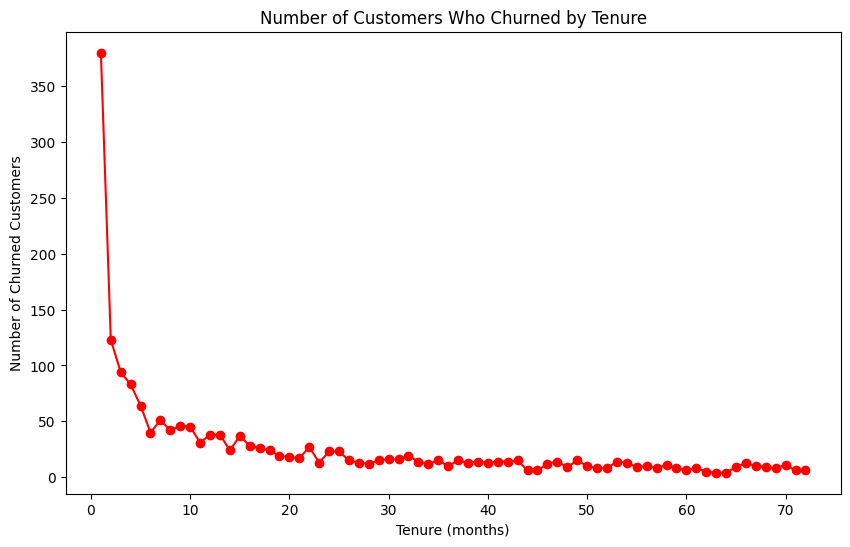

In [269]:
# NOTE: Groupby automatically sorts the groups 
x = df[df["Churn"] == "Yes"].groupby("tenure")["Churn"].count()

plt.figure(figsize=(10, 6))
plt.plot(x.index, x.values, marker="o", color="red")
plt.title("Number of Customers Who Churned by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Churned Customers")
plt.show()

### 1.4 Drop customerID

In [270]:
df = df.drop("customerID", axis=1)

### 1.5 Encode SeniorCitizen Class

In [271]:
le = LabelEncoder()

senior_citizen = df["SeniorCitizen"].copy()
senior_citizen = le.fit_transform(senior_citizen)

df["SeniorCitizen"] = senior_citizen

### 1.6 Further Encoding

In [272]:
label_encoding_cols = [
    "Partner", 
    "Dependents", 
    "PhoneService", 
    "MultipleLines", 
    "OnlineSecurity", 
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

hot_encoding_cols = [
    "gender",
    "InternetService",
    "Contract",
    "PaymentMethod"
]

for col in label_encoding_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded = ohe.fit_transform(df[hot_encoding_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(hot_encoding_cols),
    index=df.index
)

df = pd.concat(
    [df.drop(columns=hot_encoding_cols), encoded_df],
    axis=1
)

churn = df["Churn"]
df = df.drop("Churn", axis=1)
df = pd.concat([df, churn], axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,No
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Yes
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,No
4,0,0,0,2,1,0,0,0,0,0,...,151.65,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,Yes


(7032, 23)



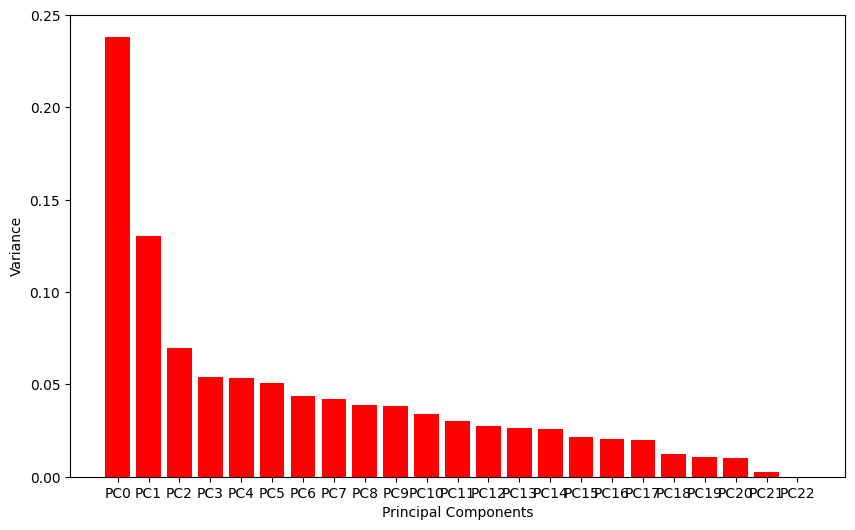

In [273]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ss = StandardScaler()

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(X.shape, end="\n\n")
scaled_X = ss.fit_transform(X)

pca = PCA()
X_pc = pca.fit_transform(scaled_X)
labels = ['PC' + str(i) for i in range(X_pc.shape[1])]
                                                                                             
plt.figure(figsize=(10, 6))
plt.bar(labels, pca.explained_variance_ratio_, color="red")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()


### 1.7 Normalize Numerical Features

In [274]:
ncols = ["tenure", "MonthlyCharges", "TotalCharges"]
numerical_cols = df[ncols]

col_max = np.max(numerical_cols, axis=0)
col_min = np.min(numerical_cols, axis=0)

numerical_cols = (numerical_cols - col_min) / (col_max - col_min)

linear_df = df.copy()
df[ncols] = numerical_cols

linear_df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,No
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Yes
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,No
4,0,0,0,2,1,0,0,0,0,0,...,151.65,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,Yes


## Section II: Model Application

### 2.1 Selecting X and y

In [275]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_lin = linear_df.iloc[:, :-1].values
y_lin = linear_df.iloc[:, -1].values

model_to_score = {}

### 2.2 Splitting Training and Testing

In [276]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_lin, y_lin, test_size=0.2)

### 2.3.1 Applying Logistic Regression

In [277]:
log_reg = LogisticRegression()
log_reg.fit(Xl_train, yl_train)

yl_pred = log_reg.predict(Xl_test)

/home/huzaifa/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2.3.2 Analyze Logistic Regression

Accuracy Score: 0.8187633262260128


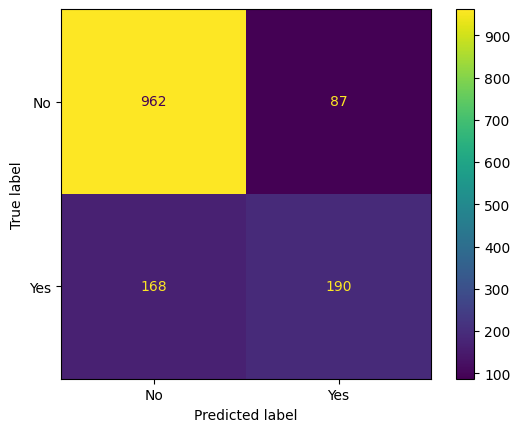

In [278]:
lr_acc_score = accuracy_score(yl_test, yl_pred)
print(f"Accuracy Score: {lr_acc_score}")

model_to_score["Logistic Regression"] = lr_acc_score

ConfusionMatrixDisplay.from_estimator(log_reg, Xl_test, yl_test)
plt.show()

### 2.4.1 Apply Decision Tree Classification

In [279]:
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)

y_pred = dec_tree.predict(X_test)

### 2.4.2 Analyze Decision Tree

Accuracy Score: 0.7164179104477612


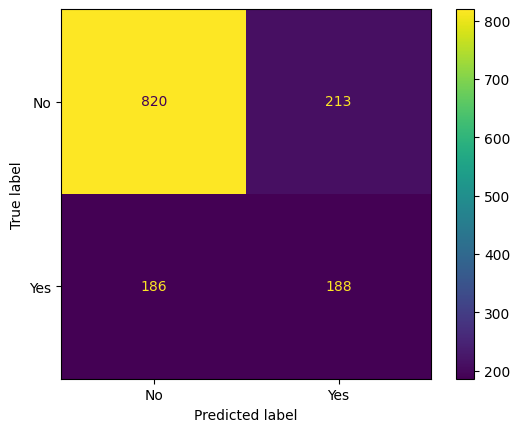

In [280]:
dec_tree_acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {dec_tree_acc_score}")
ConfusionMatrixDisplay.from_estimator(dec_tree, X_test, y_test)
plt.show()

model_to_score["Decision Tree Classifier"] = dec_tree_acc_score

### 2.5.1 Apply Random Forest 

In [281]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

### 2.5.2 Analyze Random Forest

Accuracy Score: 0.783226723525231


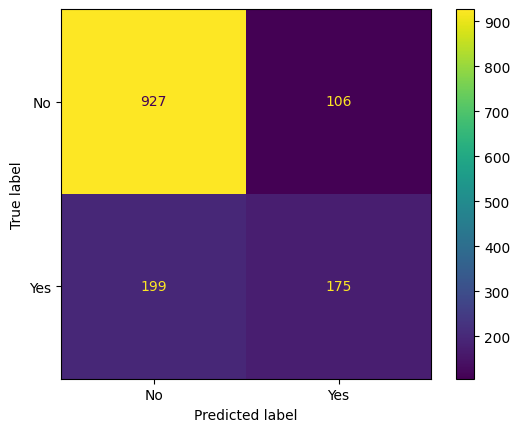

In [282]:
rand_for_acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {rand_for_acc_score}")

ConfusionMatrixDisplay.from_estimator(random_forest, X_test, y_test)
plt.show()

model_to_score["Random Forest"] = rand_for_acc_score

### 2.6.1 Apply Linear SVC

In [283]:
# svc = SVC(kernel="linear")

# svc.fit(Xl_train, yl_train)
# y_pred = svc.predict(Xl_test)

### 2.6.2 Analyze Linear SVC

In [284]:
# svc_acc_score = accuracy_score(y_test, y_pred)
# print(f"Accuracy Score: {svc_acc_score}")

# ConfusionMatrixDisplay.from_estimator(svc, Xl_test, yl_test)
# plt.show()

# model_to_score["Linear SVC"] = svc_acc_score

### 2.7.1 Apply K Nearest Neighbors

In [285]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

### 2.7.2 Analyze K Nearest Neighbors

Accuracy Score: 0.746268656716418


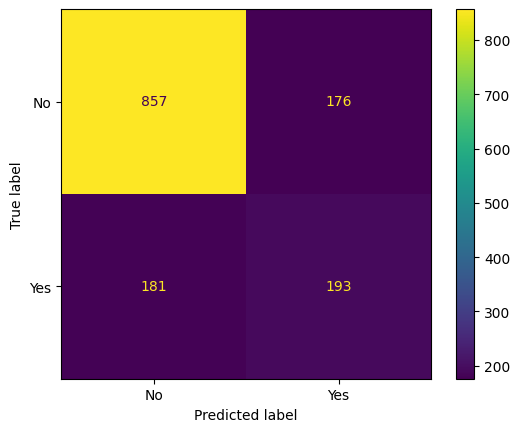

In [286]:
knn_acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {knn_acc_score}")

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.show()

model_to_score["KNN"] = knn_acc_score

In [287]:
max_idx = np.argmax(list(model_to_score.values()))
print(f"Best model: {list(model_to_score.keys())[max_idx]}")

Best model: Logistic Regression
